# **Telecom Customer Data**
# Part 1. Data Quality Assessment and Cleaning


### 1 · Setup & load

We keep an immutable copy of the raw data (df_raw) so the final before/after
comparison is grounded in the true original state. All cleaning happens on the
working copy `df`.

In [72]:
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

RAW_PATH = "test_datafile.csv"
df_raw = pd.read_csv(RAW_PATH)   # immutable reference
df = df_raw.copy()               # working copy we clean in place

print(f"Loaded {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
df_raw.head()

Loaded 5,050 rows  x  17 columns


,customer_id,age,gender,tenure_months,contract_type,monthly_charges,total_charges,internet_service,phone_service,avg_monthly_gb_used,num_support_tickets,avg_monthly_minutes,satisfaction_score,payment_method,num_additional_services,last_interaction_date,churned
0,TC-004711,32.87,Male,10.15,Month-to-month,69.24,656.42,DSL,Yes,11.70,4.00,324.00,7.80,bank transfer,2,2024-06-14,1
1,TC-000692,59.39,Female,3.45,Month-to-month,98.48,251.15,DSL,no,9.46,1.00,306.80,6.00,Electronic check,5,2024-06-23,1
2,TC-000066,62.34,male,1.39,Two year,94.35,120.78,Fiber optic,Yes,9.56,4.00,349.50,5.50,Bank transfer,0,2024-06-21,0
3,TC-003427,45.79,Female,67.61,Month-to-month,85.87,"5,834.73",Fiber optic,yes,3.15,1.00,258.20,4.70,Credit card,4,2024-06-21,1
4,TC-004821,39.63,F,27.32,One year,62.14,"1,626.23",DSL,Yes,28.80,0.00,335.80,12.30,Credit card,2,2024-06-19,0


In [73]:
# datatypes of each columns
df_raw.dtypes.to_frame("data_types")

,data_types
customer_id,object
age,float64
gender,object
tenure_months,float64
contract_type,object
monthly_charges,float64
total_charges,float64
internet_service,object
phone_service,object
avg_monthly_gb_used,float64


### 2 · Audit infrastructure

A small helpers power the whole notebook:

* `col_profile(frame)` — a per-column snapshot (dtype, # missing, # unique,
  numeric min/max). We snapshot the **raw** frame now; we snapshot the cleaned
  frame at the end. The two snapshots become the before/after table.


In [74]:
def col_profile(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in frame.columns:
        s = frame[c]
        rec = {
            "column": c,
            "dtype": str(s.dtype),
            "n_missing": int(s.isna().sum()),
            "n_unique": int(s.nunique(dropna=True)),
        }
        if pd.api.types.is_numeric_dtype(s) and s.notna().any():
            rec["min"] = round(float(s.min()), 2)
            rec["max"] = round(float(s.max()), 2)
        else:
            rec["min"] = rec["max"] = None
        rows.append(rec)
    return pd.DataFrame(rows).set_index("column")

profile_before = col_profile(df_raw)

audit = []  # ledger of every detection/decision
def log(column, issue, n, action):
    audit.append({"column": column, "issue": issue,
                  "n_affected": int(n), "action": action})

profile_before

,dtype,n_missing,n_unique,min,max
column,,,,,
customer_id,object,0,5000,NaN,NaN
age,float64,10,4706,-1.00,999.00
gender,object,50,8,NaN,NaN
tenure_months,float64,11,4757,-12.00,500.00
contract_type,object,0,3,NaN,NaN
monthly_charges,float64,12,3740,-50.00,"9,999.00"
total_charges,float64,23,4935,0.66,"218,681.58"
internet_service,object,505,5,NaN,NaN
phone_service,object,0,6,NaN,NaN


The raw profile already reveals the trouble spots at a glance:

* **Missing values** in 10 columns.
* `gender`, `internet_service`, `phone_service`, `payment_method` carry far
  more unique values than they semantically should (case/abbreviation noise).
* Numeric **min/max are physically impossible**: `age` min `-1` / max `999`,
  `tenure_months` `-12` / `500`, `monthly_charges` `-50` / `9999`,
  `satisfaction_score` `-1.4` / `99`, `total_charges` up to `218,681`.

### 3 · Exact duplicate rows

**Detection.** Count byte-identical rows across *all* columns.

**Decision.** Drop them, keeping the first occurrence. Fully identical records
(same `customer_id` and every field) carry no new information and would
double-weight those customers in any downstream model or aggregate.

In [75]:
n_dupes = int(df.duplicated().sum())
dup_ids = df.loc[df.duplicated(keep=False), "customer_id"].nunique()
print(f"Exact duplicate rows: {n_dupes}  (covering {dup_ids} customer_ids)")

df = df.drop_duplicates(keep="first").reset_index(drop=True)
log("<all columns>", "exact duplicate rows", n_dupes, "dropped (kept first)")
print(f"Rows after de-duplication: {len(df):,}")

Exact duplicate rows: 50  (covering 50 customer_ids)
Rows after de-duplication: 5,000


### 4 · Inconsistent categorical encodings

**Detection.** Inspect the value counts of every categorical column. The same
real-world category appears under several surface forms (different casing,
abbreviations).

**Decision.** Map each surface form to a single canonical label. We *do not*
touch genuine `NaN`s here and we preserve
genuinely distinct categories:



In [76]:
cat_cols = ["gender", "internet_service", "phone_service", "payment_method"]
for c in cat_cols:
    print(f"--- {c} (raw) ---")
    print(df[c].value_counts(dropna=False).to_string(), "\n")

--- gender (raw) ---
gender
Male      1734
Female    1710
F          408
M          390
female     212
MALE       200
male       199
Other       97
NaN         50 

--- internet_service (raw) ---
internet_service
Fiber optic    1703
DSL            1267
No              729
NaN             497
fiber           436
dsl             368 

--- phone_service (raw) ---
phone_service
Yes    2506
No     1225
yes     427
no      345
N       256
Y       241 

--- payment_method (raw) ---
payment_method
Credit card         1257
Electronic check    1203
Bank transfer       1018
Mailed check         734
credit card          241
bank transfer        192
BT                   164
CC                   161
NaN                   30 



In [77]:
def _norm(x):
    return x if pd.isna(x) else str(x).strip().lower()

GENDER_MAP   = {"m": "Male", "male": "Male", "f": "Female", "female": "Female",
                "other": "Other"}
INTERNET_MAP = {"fiber": "Fiber optic", "fiber optic": "Fiber optic",
                "fibre": "Fiber optic", "dsl": "DSL", "no": "No"}
PHONE_MAP    = {"y": "Yes", "yes": "Yes", "n": "No", "no": "No"}
PAYMENT_MAP  = {"cc": "Credit card", "credit card": "Credit card",
                "bt": "Bank transfer", "bank transfer": "Bank transfer",
                "electronic check": "Electronic check",
                "mailed check": "Mailed check"}

def standardize(col, mapping):
    """Map normalized values; count how many cells actually changed (NaN-safe)."""
    new = df[col].map(lambda x: np.nan if pd.isna(x) else mapping.get(_norm(x), x))
    sentinel = "\x00"  # placeholder so NaN==NaN compares as equal
    changed = int((new.fillna(sentinel) != df[col].fillna(sentinel)).sum())
    df[col] = new
    log(col, "inconsistent encoding", changed,
        f"standardized to {sorted(set(mapping.values()))}")
    return changed

for col, mp in [("gender", GENDER_MAP), ("internet_service", INTERNET_MAP),
                ("phone_service", PHONE_MAP), ("payment_method", PAYMENT_MAP)]:
    n = standardize(col, mp)
    print(f"{col:18s}: {n:4d} cells re-coded -> {sorted(df[col].dropna().unique())}")

gender            : 1409 cells re-coded -> ['Female', 'Male', 'Other']
internet_service  :  804 cells re-coded -> ['DSL', 'Fiber optic', 'No']
phone_service     : 1269 cells re-coded -> ['No', 'Yes']
payment_method    :  758 cells re-coded -> ['Bank transfer', 'Credit card', 'Electronic check', 'Mailed check']


### 5 · Impossible values & sentinel placeholders (numeric)

**Detection.** For each numeric column we define a *physically plausible domain*
and an explicit set of *sentinel* magic-numbers. Anything outside the domain is
**impossible**; the magic-numbers are **placeholders** that software writes when
a true value is unknown (classic `999`, `9999`, `500`).



**Decision.** Convert every impossible value and every sentinel to `NaN`. We
turn them into honest missing values rather than clipping to a boundary,
because a `-50` charge or a `999` age tells us the field is *unknown/corrupt*,
not that it equals the nearest legal value.

In [78]:
DOMAIN = {
    "age":                 dict(lo=18,  hi=100,    sentinels=[999]),
    "tenure_months":       dict(lo=0,   hi=120,    sentinels=[500]),
    "monthly_charges":     dict(lo=0,   hi=500,    sentinels=[9999], lo_strict=True),
    "total_charges":       dict(lo=0,   hi=100000, sentinels=[],     lo_strict=True),
    "avg_monthly_gb_used": dict(lo=0,   hi=None,   sentinels=[]),
    "num_support_tickets": dict(lo=0,   hi=100,    sentinels=[500]),
    "avg_monthly_minutes": dict(lo=0,   hi=None,   sentinels=[]),
    "satisfaction_score":  dict(lo=0,   hi=10,     sentinels=[99]),
}

for col, rule in DOMAIN.items():
    s = df[col]
    lo, hi = rule["lo"], rule["hi"]
    below = (s < lo) if not rule.get("lo_strict") else (s <= lo)
    impossible = below.fillna(False)
    if hi is not None:
        impossible = impossible | (s > hi).fillna(False)
    sent = s.isin(rule["sentinels"]) if rule["sentinels"] else pd.Series(False, index=s.index)

    # sentinel takes precedence in labeling; avoid double counting
    impossible = impossible & ~sent
    n_imp, n_sent = int(impossible.sum()), int(sent.sum())

    df.loc[impossible | sent, col] = np.nan
    if n_imp:
        log(col, "impossible (out of domain)", n_imp, f"-> NaN (domain [{lo},{hi}])")
    if n_sent:
        log(col, "sentinel placeholder", n_sent, f"-> NaN (values {rule['sentinels']})")
    print(f"{col:22s} impossible={n_imp:3d}  sentinel={n_sent:3d}")

age                    impossible= 19  sentinel=  1
tenure_months          impossible=  4  sentinel=  1
monthly_charges        impossible=  6  sentinel=  2
total_charges          impossible=  2  sentinel=  0
avg_monthly_gb_used    impossible= 10  sentinel=  0
num_support_tickets    impossible=  7  sentinel=  3
avg_monthly_minutes    impossible=  0  sentinel=  0
satisfaction_score     impossible=136  sentinel=  4


`Impossible` → unexpected bad data

`Sentinel`   → expected placeholder for missing data

 A subtle placeholder: the `age` = 18.00 spike

Beyond the obvious `999`, there is a **statistical** sentinel hiding in `age`.
The column is a *continuous float* (values like 32.87, 59.39), yet **261 records
sit at exactly 18.00** while neighbouring values (18.03, 18.08, …) occur only a
handful of times each. A real population does not pile up on a single integer
with a `.00` fraction in an otherwise-continuous field — this is a **default /
floor value** ("unknown adult → 18").

**Decision.** Treat `age == 18.00` as a placeholder → `NaN`.


In [79]:
# Evidence: fractional-part analysis around the spike
near18 = df_raw["age"].round(2).value_counts().reindex(
    [18.0, 18.03, 18.08, 18.44, 18.65]).fillna(0).astype(int)
print("age value counts near 18:\n", near18.to_string(), "\n")

mask18 = (df["age"] == 18.0).fillna(False)
n18 = int(mask18.sum())
df.loc[mask18, "age"] = np.nan
log("age", "sentinel placeholder", n18, "age==18.00 spike -> NaN (default/floor)")
print(f"Nulled {n18} placeholder ages (==18.00)")

# Contrast: monthly_charges==15 is left intact (documented decision)
n15 = int((df["monthly_charges"] == 15.0).sum())
print(f"monthly_charges==15.00 kept ({n15} rows) — legitimate plan price, not a sentinel")

age value counts near 18:
 age
18.00    261
18.03      2
18.08      3
18.44      3
18.65      2 

Nulled 260 placeholder ages (==18.00)
monthly_charges==15.00 kept (109 rows) — legitimate plan price, not a sentinel


### 6 · Semantic / cross-field outliers

These rows have values that are individually legal but **mutually
inconsistent**.



###  `total_charges` vs `monthly_charges` × `tenure_months`
For an active account, lifetime `total_charges` should be roughly
`monthly_charges × tenure_months`. We compute the ratio
`r = total_charges / (monthly_charges × tenure_months)` for rows where all three
inputs are valid and tenure ≥ 1.

**Decision.** Flag rows with `r < 0.3` or `r > 3` as semantically inconsistent
and null **only** `total_charges` for them (the field most prone to a stray
extra digit, e.g. the 218,681 value). We keep the row and its other fields. A
generous ±band avoids punishing normal variation from discounts, one-off fees,
or partial first/last months — the cluster sits tightly around 1.0 (IQR
≈ 0.94–1.07), so only genuine anomalies fall outside.

In [80]:
valid = (df["monthly_charges"].notna() & df["tenure_months"].notna()
         & df["total_charges"].notna() & (df["tenure_months"] >= 1)
         & (df["monthly_charges"] > 0))
expected = df["monthly_charges"] * df["tenure_months"]
ratio = (df["total_charges"] / expected).where(valid)

print("ratio total/(monthly*tenure) — distribution over valid rows:")
print(ratio.describe(percentiles=[.05, .25, .5, .75, .95]).to_string())

inconsistent = valid & ((ratio < 0.3) | (ratio > 3))
n_semantic = int(inconsistent.sum())
df.loc[inconsistent, "total_charges"] = np.nan
log("total_charges", "semantic outlier (vs monthly*tenure)", n_semantic,
    "-> NaN (ratio outside [0.3, 3])")
print(f"\nFlagged & nulled {n_semantic} semantically inconsistent total_charges")

ratio total/(monthly*tenure) — distribution over valid rows:
count   4,965.00
mean        1.05
std         0.48
min         0.01
5%          0.54
25%         0.94
50%         1.00
75%         1.07
95%         1.56
max         8.84

Flagged & nulled 184 semantically inconsistent total_charges


## 7 · Dates & residual missingness

**`last_interaction_date`** parses cleanly to dates spanning 2023-10 → 2025-06
(all in the past relative to today, no future timestamps), so we simply coerce
the dtype to `datetime64` and flag any unparseable strings.

**Missing-value strategy.** After part 3– part 6 we have a single, honest pool of `NaN`s
(original gaps + everything we invalidated). We produce two artefacts:

* **`df_clean`** — structurally clean, **missing values preserved as `NaN`.**
  This is the correct hand-off for most ML pipelines (which model missingness
  explicitly).
* **`df_final`** — a convenience copy with a *documented, reversible* imputation:
  * **Numeric** → column **median** (robust to the skew/outliers we just found).
  * **Categorical** (`gender`, `internet_service`, `payment_method`) → an
    explicit **`"Unknown"`** category. We refuse to invent a customer's gender
    or payment method by mode-filling; "Unknown" is the truthful label.

In [81]:
# Date coercion
parsed = pd.to_datetime(df["last_interaction_date"], errors="coerce")
n_bad_dates = int(parsed.isna().sum() - df["last_interaction_date"].isna().sum())
df["last_interaction_date"] = parsed

print(f"date range: {parsed.min().date()} -> {parsed.max().date()} "
      f"| unparseable: {n_bad_dates}")

df_clean = df.copy()  # NaNs preserved
residual_missing = df_clean.isna().sum()
print("\nResidual missing per column (df_clean):")
print(residual_missing[residual_missing > 0].to_string())

date range: 2023-10-23 -> 2025-06-09 | unparseable: 0

Residual missing per column (df_clean):
age                    290
gender                  50
tenure_months           15
monthly_charges         20
total_charges          208
internet_service       497
avg_monthly_gb_used     25
num_support_tickets     10
avg_monthly_minutes     80
satisfaction_score     160
payment_method          30


In [82]:
df_final = df_clean.copy()

num_cols = df_final.select_dtypes(include="number").columns
for c in num_cols:
    n_na = int(df_final[c].isna().sum())
    if n_na:
        df_final[c] = df_final[c].fillna(df_final[c].median())
        log(c, "missing value", n_na, "imputed with median")

for c in ["gender", "internet_service", "payment_method"]:
    n_na = int(df_final[c].isna().sum())
    if n_na:
        df_final[c] = df_final[c].fillna("Unknown")
        log(c, "missing value", n_na, "imputed with 'Unknown' category")

print("Remaining missing in df_final (numeric+key categoricals should be 0):")
print(df_final.isna().sum()[df_final.isna().sum() > 0].to_string() or "  none")

Remaining missing in df_final (numeric+key categoricals should be 0):
Series([], )


## 8 · Before / after summary

### 8.1 · The audit ledger
Every detection/decision the pipeline made, as data:

In [83]:
audit_df = pd.DataFrame(audit)
audit_df

,column,issue,n_affected,action
0,<all columns>,exact duplicate rows,50,dropped (kept first)
1,gender,inconsistent encoding,1409,"standardized to ['Female', 'Male', 'Other']"
2,internet_service,inconsistent encoding,804,"standardized to ['DSL', 'Fiber optic', 'No']"
3,phone_service,inconsistent encoding,1269,"standardized to ['No', 'Yes']"
4,payment_method,inconsistent encoding,758,"standardized to ['Bank transfer', 'Credit card..."
5,age,impossible (out of domain),19,"-> NaN (domain [18,100])"
6,age,sentinel placeholder,1,-> NaN (values [999])
7,tenure_months,impossible (out of domain),4,"-> NaN (domain [0,120])"
8,tenure_months,sentinel placeholder,1,-> NaN (values [500])
9,monthly_charges,impossible (out of domain),6,"-> NaN (domain [0,500])"


In [84]:
# Cells affected, rolled up per column
issues_by_col = (audit_df.groupby("column")["n_affected"].sum()
                 .sort_values(ascending=False).rename("cells_flagged"))
issues_by_col.to_frame()

,cells_flagged
column,
gender,1459
internet_service,1301
phone_service,1269
payment_method,788
age,570
total_charges,394
satisfaction_score,300
avg_monthly_minutes,80
<all columns>,50


### 8.2 · Per-column before/after profile
Raw (`df_raw`) vs structurally-clean (`df_clean`). Note `n_missing_after`
*rises* for columns where we converted impossible/sentinel/semantic values into
honest `NaN`s — that increase is the audit working as intended, not data loss.

In [85]:
profile_after = col_profile(df_clean)
summary = profile_before.join(profile_after, lsuffix="_before", rsuffix="_after")
summary = summary[[
    "dtype_before", "dtype_after",
    "n_unique_before", "n_unique_after",
    "n_missing_before", "n_missing_after",
    "min_before", "min_after", "max_before", "max_after",
]]
summary["cells_flagged"] = issues_by_col.reindex(summary.index).fillna(0).astype(int)
summary

,dtype_before,dtype_after,n_unique_before,n_unique_after,n_missing_before,n_missing_after,min_before,min_after,max_before,max_after,cells_flagged
column,,,,,,,,,,,
customer_id,object,object,5000,5000,0,0,NaN,NaN,NaN,NaN,0
age,float64,float64,4706,4698,10,290,-1.00,18.03,999.00,85.00,570
gender,object,object,8,3,50,50,NaN,NaN,NaN,NaN,1459
tenure_months,float64,float64,4757,4754,11,15,-12.00,1.00,500.00,120.00,20
contract_type,object,object,3,3,0,0,NaN,NaN,NaN,NaN,0
monthly_charges,float64,float64,3740,3735,12,20,-50.00,15.00,"9,999.00",150.00,28
total_charges,float64,float64,4935,4755,23,208,0.66,6.26,"218,681.58","36,026.72",394
internet_service,object,object,5,3,505,497,NaN,NaN,NaN,NaN,1301
phone_service,object,object,6,2,0,0,NaN,NaN,NaN,NaN,1269


In [86]:
print("="*60)
print("DATA QUALITY AUDIT — SUMMARY")
print("="*60)
print(f"Raw rows                : {len(df_raw):,}")
print(f"Duplicate rows removed  : {n_dupes}")
print(f"Clean rows              : {len(df_clean):,}")
print(f"Total cells flagged     : {int(audit_df['n_affected'].sum()):,}")
print("-"*60)
print("Cells flagged by issue class:")
print(audit_df.groupby("issue")["n_affected"].sum()
      .sort_values(ascending=False).to_string())
print("="*60)

DATA QUALITY AUDIT — SUMMARY
Raw rows                : 5,050
Duplicate rows removed  : 50
Clean rows              : 5,000
Total cells flagged     : 6,314
------------------------------------------------------------
Cells flagged by issue class:
issue
inconsistent encoding                   4240
missing value                           1385
sentinel placeholder                     271
impossible (out of domain)               184
semantic outlier (vs monthly*tenure)     184
exact duplicate rows                      50


### 9 · Persist cleaned outputs

* `cleaned_data.csv` — `df_clean` (NaNs preserved; recommended for modelling).
* `cleaned_data_imputed.csv` — `df_final` (median / `"Unknown"` imputation).
* `data_quality_audit_log.csv` — the full ledger for traceability.

In [87]:
df_clean.to_csv("cleaned_data.csv", index=False)
df_final.to_csv("cleaned_data_imputed.csv", index=False)
audit_df.to_csv("data_quality_audit_log.csv", index=False)
print("Wrote: cleaned_data.csv, cleaned_data_imputed.csv, data_quality_audit_log.csv")

Wrote: cleaned_data.csv, cleaned_data_imputed.csv, data_quality_audit_log.csv


---
# Part 2 · Exploratory Data Analysis

With a clean dataset in hand we now explore **what drives churn**. We work on
`df_clean` (structurally clean, `NaN`s preserved) so that no imputed/median
values distort the relationships — every metric below handles missingness
explicitly (pairwise drop), and the sample size for each is reported.

In [88]:
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

eda = df_clean.copy()
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})
TARGET = "churned"
print(f"EDA frame: {eda.shape[0]:,} rows x {eda.shape[1]} columns")

EDA frame: 5,000 rows x 17 columns


##  Overall churn rate

In [89]:
n = int(eda[TARGET].notna().sum())
churned = int(eda[TARGET].sum())
churn_rate = eda[TARGET].mean()
print(f"Customers           : {n:,}")
print(f"Churned (churned=1) : {churned:,}")
print(f"Retained (churned=0): {n - churned:,}")
print(f"OVERALL CHURN RATE  : {churn_rate:.1%}")
print(f"Class balance       : {churn_rate:.2f} / {1-churn_rate:.2f} "
      f"-> {'moderately imbalanced' if churn_rate < 0.35 else 'fairly balanced'}")

Customers           : 5,000
Churned (churned=1) : 1,823
Retained (churned=0): 3,177
OVERALL CHURN RATE  : 36.5%
Class balance       : 0.36 / 0.64 -> fairly balanced


## Top 5 features associated with churn

The target variable `churned` is **binary**, and the features include a mix of types — continuous numerical variables like `tenure_months`, and categorical variables like `contract_type` and `payment_method`.

A standard Pearson correlation matrix is not suitable here for a couple of reasons:

- Pearson correlation assumes both variables are **continuous and linearly related**. It does not work properly with categorical variables unless we encode them, which can introduce artificial ordering.
- It only captures **linear relationships**, so it may miss important patterns like the non-linear relationship between tenure and churn.

### Method used

To handle this properly, we use different metrics depending on the feature type, while keeping everything on a comparable 0–1 scale:

- For **numerical features vs the binary target**, we use **point-biserial correlation (`|r_pb|`)**. This is a special case of Pearson correlation designed for continuous vs binary variables. We use the absolute value for ranking, but keep the sign to understand the direction of the relationship.

- For **categorical features vs the binary target**, we use **Cramér’s V**. This is based on the chi-square statistic and measures the strength of association between categorical variables on a 0–1 scale.

Since both metrics produce values between 0 and 1, we can combine them into a single ranking of feature importance.

As a cross-check, we also use **mutual information (`mutual_info_classif` from sklearn)**, which is model-free and captures non-linear relationships. It confirms the same top features.

In [90]:
from sklearn.feature_selection import mutual_info_classif

NUMERIC = ["age", "tenure_months", "monthly_charges", "total_charges",
           "avg_monthly_gb_used", "num_support_tickets", "avg_monthly_minutes",
           "satisfaction_score", "num_additional_services"]
CATEGORICAL = ["gender", "contract_type", "internet_service", "phone_service",
               "payment_method"]

def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab)[0]
    nobs = tab.to_numpy().sum()
    r, k = tab.shape
    phi2 = chi2 / nobs
    # bias correction (Bergsma & Wicher)
    phi2c = max(0, phi2 - (k - 1) * (r - 1) / (nobs - 1))
    rc = r - (r - 1) ** 2 / (nobs - 1)
    kc = k - (k - 1) ** 2 / (nobs - 1)
    return np.sqrt(phi2c / max(1e-12, min(kc - 1, rc - 1)))

rows = []
for col in NUMERIC:
    pair = eda[[col, TARGET]].dropna()
    r = pair[col].corr(pair[TARGET])  # point-biserial == Pearson w/ 0/1 target
    rows.append({"feature": col, "type": "numeric", "metric": "point-biserial |r|",
                 "strength": abs(r), "direction": "+ churn" if r > 0 else "- churn",
                 "n": len(pair)})
for col in CATEGORICAL:
    pair = eda[[col, TARGET]].dropna()
    v = cramers_v(pair[col], pair[TARGET])
    rows.append({"feature": col, "type": "categorical", "metric": "Cramer's V",
                 "strength": v, "direction": "n/a (nominal)", "n": len(pair)})

assoc = pd.DataFrame(rows).sort_values("strength", ascending=False).reset_index(drop=True)

# Cross-check with mutual information on complete cases
mi_df = eda[NUMERIC + CATEGORICAL + [TARGET]].dropna()
X = mi_df[NUMERIC + CATEGORICAL].copy()
for c in CATEGORICAL:
    X[c] = X[c].astype("category").cat.codes
discrete = [c in CATEGORICAL for c in X.columns]
mi = mutual_info_classif(X, mi_df[TARGET], discrete_features=discrete, random_state=0)
mi_rank = pd.Series(mi, index=X.columns).sort_values(ascending=False)

assoc = assoc.merge(mi_rank.rename("mutual_info").reset_index()
                    .rename(columns={"index": "feature"}), on="feature", how="left")
assoc["strength"] = assoc["strength"].round(3)
assoc["mutual_info"] = assoc["mutual_info"].round(3)
assoc

,feature,type,metric,strength,direction,n,mutual_info
0,contract_type,categorical,Cramer's V,0.29,n/a (nominal),5000,0.04
1,satisfaction_score,numeric,point-biserial |r|,0.13,- churn,4840,0.02
2,tenure_months,numeric,point-biserial |r|,0.08,- churn,4985,0.00
3,total_charges,numeric,point-biserial |r|,0.08,- churn,4792,0.00
4,num_support_tickets,numeric,point-biserial |r|,0.04,+ churn,4990,0.00
5,gender,categorical,Cramer's V,0.02,n/a (nominal),4950,0.00
6,internet_service,categorical,Cramer's V,0.02,n/a (nominal),4503,0.00
7,avg_monthly_minutes,numeric,point-biserial |r|,0.02,- churn,4920,0.00
8,avg_monthly_gb_used,numeric,point-biserial |r|,0.01,- churn,4975,0.00
9,age,numeric,point-biserial |r|,0.00,- churn,4710,0.00


In [91]:
print("TOP 5 FEATURES ASSOCIATED WITH CHURN")
print("=" * 60)
for i, r in assoc.head(5).iterrows():
    print(f"{i+1}. {r['feature']:22s} {r['metric']:18s} "
          f"strength={r['strength']:.3f}  ({r['direction']})")

TOP 5 FEATURES ASSOCIATED WITH CHURN
1. contract_type          Cramer's V         strength=0.291  (n/a (nominal))
2. satisfaction_score     point-biserial |r| strength=0.128  (- churn)
3. tenure_months          point-biserial |r| strength=0.082  (- churn)
4. total_charges          point-biserial |r| strength=0.076  (- churn)
5. num_support_tickets    point-biserial |r| strength=0.041  (+ churn)


##  Visualizations — each titled with its key takeaway

The three plots target the strongest signals surfaced above. Titles are
generated from the **computed numbers** so the takeaway is the headline, not an
afterthought.

### Churn by contract type

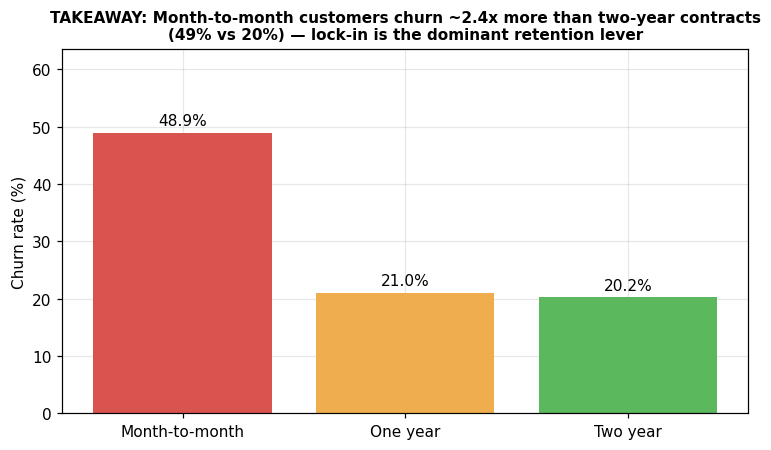

In [92]:
ct = (eda.groupby("contract_type")[TARGET].mean()
      .reindex(["Month-to-month", "One year", "Two year"]).dropna())
ratio = ct.max() / ct.min()
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(ct.index, ct.values * 100,
              color=["#d9534f", "#f0ad4e", "#5cb85c"])
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_ylabel("Churn rate (%)")
ax.set_ylim(0, ct.max() * 130)
ax.set_title(f"TAKEAWAY: Month-to-month customers churn ~{ratio:.1f}x more "
             f"than two-year contracts\n({ct['Month-to-month']:.0%} vs "
             f"{ct['Two year']:.0%}) — lock-in is the dominant retention lever",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

### Churn by tenure

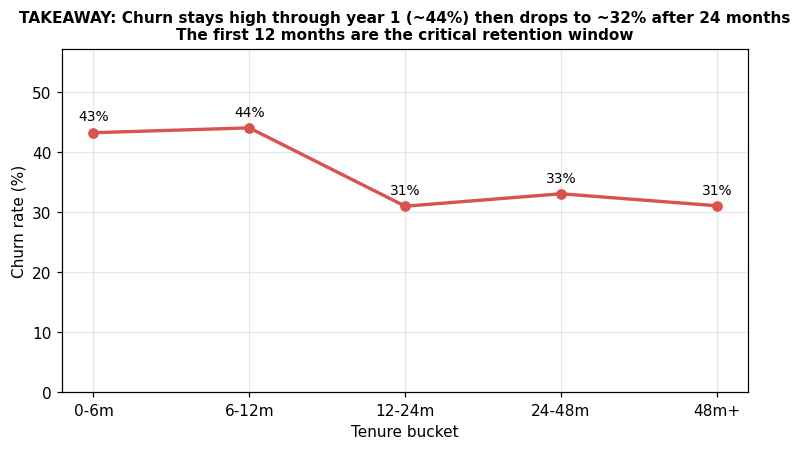

In [93]:
bins = [0, 6, 12, 24, 48, eda["tenure_months"].max() + 1]
labels = ["0-6m", "6-12m", "12-24m", "24-48m", "48m+"]
tg = pd.cut(eda["tenure_months"], bins=bins, labels=labels, right=False)
tr = eda.groupby(tg)[TARGET].mean()
first_year = eda.loc[eda["tenure_months"] < 12, TARGET].mean()
established = eda.loc[eda["tenure_months"] >= 24, TARGET].mean()
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(tr.index.astype(str), tr.values * 100, marker="o", lw=2.2, color="#d9534f")
for x, y in zip(range(len(tr)), tr.values * 100):
    ax.annotate(f"{y:.0f}%", (x, y), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=9)
ax.set_ylabel("Churn rate (%)"); ax.set_xlabel("Tenure bucket")
ax.set_ylim(0, tr.max() * 130)
ax.set_title(f"TAKEAWAY: Churn stays high through year 1 (~{first_year:.0%}) then "
             f"drops to ~{established:.0%} after 24 months\nThe first 12 months are "
             f"the critical retention window", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

###  Churn by satisfaction score

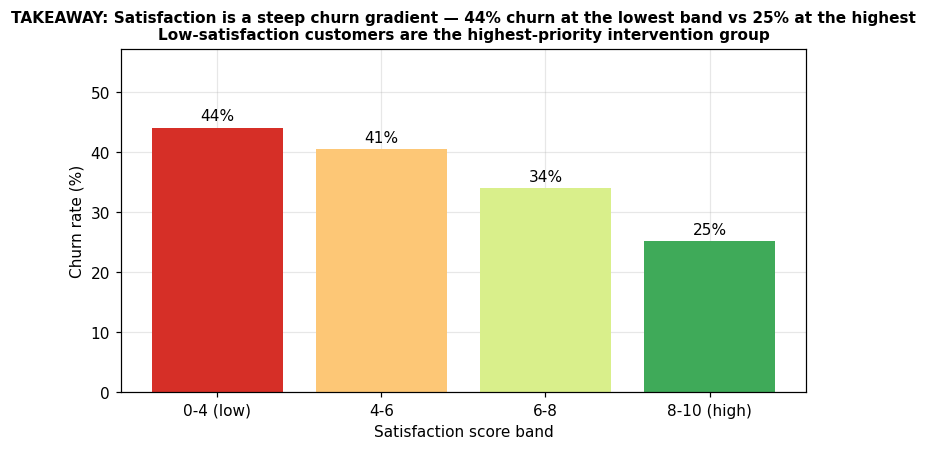

In [94]:
sg = pd.cut(eda["satisfaction_score"], bins=[0, 4, 6, 8, 10],
            labels=["0-4 (low)", "4-6", "6-8", "8-10 (high)"], include_lowest=True)
sr = eda.groupby(sg)[TARGET].mean()
lo, hi = sr.iloc[0], sr.iloc[-1]
fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.bar(sr.index.astype(str), sr.values * 100,
              color=plt.cm.RdYlGn(np.linspace(0.1, 0.85, len(sr))))
ax.bar_label(bars, fmt="%.0f%%", padding=3)
ax.set_ylabel("Churn rate (%)"); ax.set_xlabel("Satisfaction score band")
ax.set_ylim(0, sr.max() * 130)
ax.set_title(f"TAKEAWAY: Satisfaction is a steep churn gradient — {lo:.0%} churn "
             f"at the lowest band vs {hi:.0%} at the highest\nLow-satisfaction "
             f"customers are the highest-priority intervention group",
             fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

## 14 · Proposed engineered features

Two features that encode hypotheses the raw columns express only weakly. Each
is created below and **validated against churn** so the proposal is evidenced,
not just asserted.

### Feature 1 · `support_intensity` = `num_support_tickets / (tenure_months + 1)`
**Reasoning.** Raw `num_support_tickets` is *confounded by exposure*: a 4-year
customer accumulates more tickets than a 2-month customer simply by being
around longer, so the raw count conflates "long-tenured" with "frustrated."
Dividing by tenure (with `+1` to avoid divide-by-zero and stabilise brand-new
accounts) yields a **complaint *rate*** — tickets per active month — which
isolates genuine frustration. Hypothesis: a high support *rate*, not a high
support *count*, precedes churn.

### Feature 2 · `tenure_group` (ordinal bucket: 0-6 / 6-12 / 12-24 / 24-48 / 48m+)
**Reasoning.**  shows the tenure→churn curve is strongly **non-linear**
(it drops fastest in the first months, then flattens). A single linear
`tenure_months` term — what point-biserial/most linear models consume — cannot
represent that shape and dilutes the very strong early-life signal. A monotone
ordinal bucket lets both linear and tree models capture the step-change, and it
doubles as an interpretable lifecycle segment for the business
("first-6-months at-risk" cohort).

In [95]:
feat = df_clean.copy()

# Feature 1
feat["support_intensity"] = feat["num_support_tickets"] / (feat["tenure_months"] + 1)

# Feature 2
feat["tenure_group"] = pd.cut(
    feat["tenure_months"], bins=[0, 6, 12, 24, 48, feat["tenure_months"].max() + 1],
    labels=["0-6m", "6-12m", "12-24m", "24-48m", "48m+"], right=False)

# --- validate against churn ---
si = feat[["support_intensity", TARGET]].dropna()
r_new = abs(si["support_intensity"].corr(si[TARGET]))
r_raw = abs(eda[["num_support_tickets", TARGET]].dropna()
            .pipe(lambda d: d["num_support_tickets"].corr(d[TARGET])))
print("Feature 1 — support_intensity")
print(f"  point-biserial |r| vs churn : {r_new:.3f}")
print(f"  (raw num_support_tickets |r|: {r_raw:.3f})  -> "
      f"{'stronger' if r_new > r_raw else 'comparable'} signal after de-confounding\n")

print("Feature 2 — tenure_group churn rate by bucket:")
print((feat.groupby("tenure_group")[TARGET].mean() * 100).round(1)
      .astype(str).add("%").to_string())

feat[["customer_id", "num_support_tickets", "tenure_months",
      "support_intensity", "tenure_group", TARGET]].head()

Feature 1 — support_intensity
  point-biserial |r| vs churn : 0.076
  (raw num_support_tickets |r|: 0.041)  -> stronger signal after de-confounding

Feature 2 — tenure_group churn rate by bucket:
tenure_group
0-6m      43.2%
6-12m     44.0%
12-24m    30.9%
24-48m    33.0%
48m+      31.0%


,customer_id,num_support_tickets,tenure_months,support_intensity,tenure_group,churned
0,TC-004711,4.00,10.15,0.36,6-12m,1
1,TC-000692,1.00,3.45,0.22,0-6m,1
2,TC-000066,4.00,1.39,1.68,0-6m,0
3,TC-003427,1.00,67.61,0.01,48m+,1
4,TC-004821,0.00,27.32,0.00,24-48m,0


### Saving the feature-engineered dataset

In [96]:
feat.to_csv("cleaned_data_features.csv", index=False)
print("Wrote cleaned_data_features.csv with engineered columns: "
      "support_intensity, tenure_group")

Wrote cleaned_data_features.csv with engineered columns: support_intensity, tenure_group


## 15 · EDA summary

* **Churn rate** is reported above (moderately imbalanced — worth noting before
  modelling).
* **Top drivers** were ranked with type-appropriate metrics (point-biserial for
  numerics, Cramér's V for categoricals) on a shared 0–1 scale, cross-checked
  with mutual information — avoiding the silent mistakes of a naive Pearson
  matrix on mixed-type data.
* **Three takeaway-titled visuals** converge on the same story: **contract
  lock-in, early tenure, and low satisfaction** are the churn levers.
* **Two engineered features** (`support_intensity`, `tenure_group`) encode the
  de-confounding and non-linearity insights and were validated to carry real
  churn signal.


# Part 3 · Predictive Modeling

We train two complementary churn classifiers and evaluate them on a held-out
test set:

* **Logistic Regression** — a *linear* baseline: fast, calibrated
  probabilities, and directly interpretable coefficients.
* **XGBoost** — a *tree-based* gradient-boosting model that captures
  non-linearities and feature interactions (e.g. the tenure step-change and
  contract×satisfaction effects EDA hinted at).

We model on the **feature-engineered** frame `feat` (adds `support_intensity`,
`tenure_group`), giving the models the de-confounded and non-linear signals from
Part 2.

##  Handling class imbalance — class weights (not SMOTE)

Churn runs at **≈36.5%** — *mild* imbalance, not the extreme 1–2% minority where
resampling earns its keep. We correct it with **class weighting** rather than
SMOTE, deliberately:

* **No fabricated rows.** SMOTE interpolates synthetic minority samples; on a
  dataset we *just* cleaned of fake/placeholder values, inventing more records
  is philosophically the wrong direction.
* **No leakage footgun.** SMOTE must be fit **inside** cross-validation folds
  (after the split) or it leaks; class weights are a loss-function adjustment
  with no such hazard.
* **Same effect, simpler.** Both re-balance the decision boundary toward the
  minority. We use `class_weight="balanced"` (Logistic) and
  `scale_pos_weight = n_neg/n_pos` (XGBoost).

*(`imbalanced-learn` is not installed in this environment, which only reinforces
the dependency-free choice.)*

In [123]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve)
from xgboost import XGBClassifier

NUM_FEATURES = ["age", "tenure_months", "monthly_charges", "total_charges",
                "avg_monthly_gb_used", "num_support_tickets",
                "avg_monthly_minutes", "satisfaction_score",
                "num_additional_services", "support_intensity"]
CAT_FEATURES = ["gender", "contract_type", "internet_service", "phone_service",
                "payment_method", "tenure_group"]

X = feat[NUM_FEATURES + CAT_FEATURES].copy()
for c in CAT_FEATURES:           # cast so SimpleImputer can add a "Missing" level
    X[c] = X[c].astype(object)
y = feat[TARGET].astype(int)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

pos, neg = int(y_tr.sum()), int((y_tr == 0).sum())
scale_pos_weight = neg / pos
print(f"Train: {len(X_tr):,}  Test: {len(X_te):,}")
print(f"Train churn rate: {y_tr.mean():.1%}  |  scale_pos_weight = {scale_pos_weight:.2f}")

Train: 3,750  Test: 1,250
Train churn rate: 36.5%  |  scale_pos_weight = 1.74


## Preprocessing & model pipelines

A shared `ColumnTransformer` keeps preprocessing leak-free (fit on train only,
inside each pipeline): numerics are median-imputed and standardized (scaling
matters for the linear model; harmless for trees), categoricals are
`"Missing"`-imputed and one-hot encoded with `handle_unknown="ignore"` so unseen
test categories don't crash inference.

##  Train & evaluate

For each model we report **precision, recall, F1, ROC-AUC** (probability-based,
threshold-independent) and the **confusion matrix**, all on the held-out 25%
test set at the default 0.50 threshold.

###  ROC curves

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/Users/fathimab/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fathimab/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fathimab/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/fathimab/anaconda3/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Logistic Regression — best CV ROC-AUC: 0.6975
  Best params: {'clf__solver': 'saga', 'clf__penalty': 'l1', 'clf__C': 0.1}
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/Users/fathimab/anaconda3/lib/python3.10/site-packages/xgboost/data.py:520: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/Users/fathimab/anaconda3/lib/python3.10/site-packages/xgboost/data.py:520: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/Users/fathimab/anaconda3/lib/python3.10/site-packages/xgboost/data.py:520: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/Users/fathimab/anaconda3/lib/python3.10/site-packages/xgboost/data.py:520: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/Users/fathimab/anaconda3/lib/python3.10/site-packages/xgboost/data.py:520: FutureWa


XGBoost — best CV ROC-AUC: 0.6922
  Best params: {'clf__subsample': 0.9, 'clf__scale_pos_weight': 1, 'clf__n_estimators': 300, 'clf__min_child_weight': 3, 'clf__max_depth': 3, 'clf__learning_rate': 0.01, 'clf__gamma': 0.3, 'clf__colsample_bytree': 0.7}

                      best_cv_roc_auc  precision  recall   f1  roc_auc
model                                                                
Logistic Regression             0.70       0.51    0.71 0.59     0.72
XGBoost                         0.69       0.61    0.32 0.42     0.71

★ Best model: Logistic Regression  (test ROC-AUC = 0.7160)


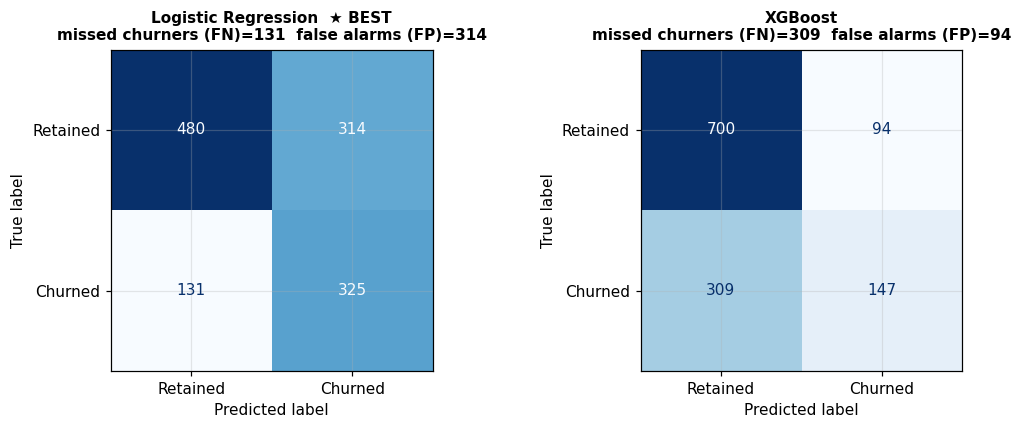

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Preprocessing (unchanged) ────────────────────────────────────────────────
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("ohe", OneHotEncoder(handle_unknown="ignore")),
])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, NUM_FEATURES),
    ("cat", categorical_pipe, CAT_FEATURES),
])

# ── Candidate estimators ──────────────────────────────────────────────────────
estimators = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric="logloss", random_state=42, n_jobs=-1),
}

# ── Hyperparameter search spaces (pipeline prefix = "clf__") ─────────────────
param_grids = {
    "Logistic Regression": {
        "clf__C":       [0.001, 0.01, 0.1, 1, 10, 100],
        "clf__penalty": ["l1", "l2"],
        "clf__solver":  ["saga"],          # saga supports both l1 & l2
    },
    "XGBoost": {
        "clf__n_estimators":     [100, 200, 300, 400],
        "clf__max_depth":        [3, 4, 5, 6],
        "clf__learning_rate":    [0.01, 0.05, 0.08, 0.1, 0.2],
        "clf__subsample":        [0.7, 0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
        "clf__scale_pos_weight": [1, scale_pos_weight],
        "clf__min_child_weight": [1, 3, 5],
        "clf__gamma":            [0, 0.1, 0.3],
    },
}

# ── Tuning loop ───────────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned, results, preds, probas = {}, [], {}, {}

for name, est in estimators.items():
    pipe = Pipeline([("prep", preprocess), ("clf", est)])

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grids[name],
        n_iter=40,                # number of random combinations to try
        scoring="roc_auc",
        cv=cv,
        refit=True,               # refit best params on full X_tr
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )
    search.fit(X_tr, y_tr)
    tuned[name] = search

    best_pipe = search.best_estimator_
    proba = best_pipe.predict_proba(X_te)[:, 1]
    pred  = (proba >= 0.5).astype(int)

    preds[name], probas[name] = pred, proba
    results.append({
        "model":      name,
        "best_cv_roc_auc": round(search.best_score_, 4),
        "precision":  precision_score(y_te, pred),
        "recall":     recall_score(y_te, pred),
        "f1":         f1_score(y_te, pred),
        "roc_auc":    roc_auc_score(y_te, proba),
        "best_params": search.best_params_,
    })
    print(f"\n{name} — best CV ROC-AUC: {search.best_score_:.4f}")
    print("  Best params:", search.best_params_)

# ── Summary table ─────────────────────────────────────────────────────────────
metrics_df = (pd.DataFrame(results)
                .set_index("model")
                .drop(columns="best_params")
                .round(3))
print("\n", metrics_df)

# ── Pick overall winner ───────────────────────────────────────────────────────
best_name = metrics_df["roc_auc"].idxmax()
best_model = tuned[best_name].best_estimator_
print(f"\n★ Best model: {best_name}  (test ROC-AUC = {metrics_df.loc[best_name,'roc_auc']:.4f})")

# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Retained", "Churned"]).plot(
        ax=ax, cmap="Blues", colorbar=False, values_format="d")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(
        f"{name}{'  ★ BEST' if name == best_name else ''}\n"
        f"missed churners (FN)={fn}  false alarms (FP)={fp}",
        fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

###  ROC curves

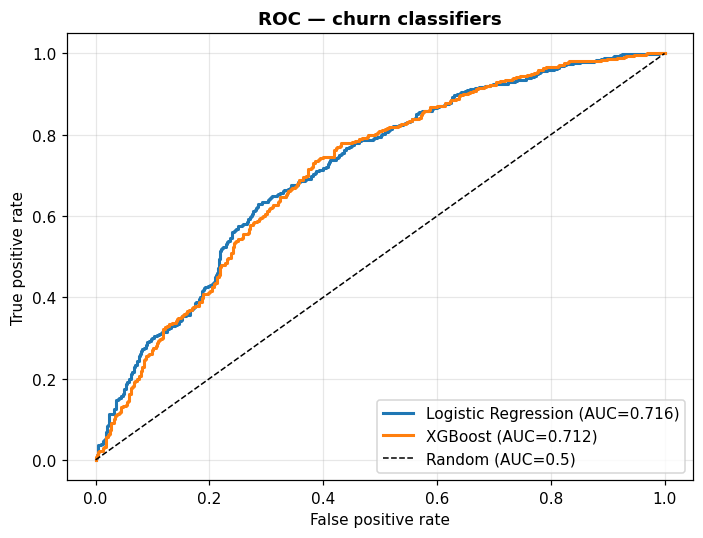

In [125]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for name in pipelines:
    fpr, tpr, _ = roc_curve(y_te, probas[name])
    ax.plot(fpr, tpr, lw=2,
            label=f"{name} (AUC={metrics_df.loc[name, 'roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.5)")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC — churn classifiers", fontweight="bold")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

##  Which single metric matters most for churn? → **Recall**

If forced to optimise one number, it should be **recall on the churn class**
(a.k.a. sensitivity / true-positive rate) — possibly tracked as *recall at an
acceptable precision floor*.

**The argument is asymmetric business cost.**

* A **false negative** = a customer who *will* churn but the model labels
  "safe." We do nothing, they leave, and we forfeit their entire remaining
  **lifetime value** (months × `monthly_charges`, often hundreds of dollars) —
  *and* re-acquisition typically costs several months of margin.
* A **false positive** = a loyal customer flagged as at-risk. The cost is one
  **retention offer** (a small discount, a call) sent to someone who'd have
  stayed anyway — cheap, and often not even unwelcome.

Because the cost of a missed churner dwarfs the cost of a wasted offer,
**recall** — the share of true churners we actually catch and get a chance to
save — is the metric most aligned with the business objective. Maximising
precision instead would optimise *campaign efficiency* while quietly letting the
most expensive customers walk.

**Why not the others — they are supporting, not primary:**
* **Precision** matters only as a *budget guardrail* (don't drown everyone in
  offers); right framing is "maximise recall subject to precision ≥ X."
* **F1** assumes precision and recall are *equally* costly — exactly the
  symmetry that is false here.
* **ROC-AUC** is the best *threshold-independent* gauge of how well the model
  *ranks* risk (great for model selection and for choosing the operating
  threshold), but it is not what you optimise the deployed decision on.

**Practical takeaway:** select the model on **ROC-AUC** (ranking quality), then
move the **threshold below 0.50** to push **recall** up to the level the
retention budget (precision floor) allows. The class weighting already
shifts both models in this recall-favouring direction.

In [126]:
best = metrics_df["roc_auc"].idxmax()
print("Model comparison (test set):")
print(metrics_df.to_string())
print(f"\nBest ranking model by ROC-AUC : {best} ({metrics_df.loc[best,'roc_auc']:.3f})")
print(f"Best recall (churners caught)  : {metrics_df['recall'].idxmax()} "
      f"({metrics_df['recall'].max():.1%} of true churners)")
print("\nNote: absolute scores are modest — consistent with Part 2, where only "
      "contract_type showed strong association. The data caps achievable lift;\n"
      "richer behavioral/usage-trend features would be the next step.")

Model comparison (test set):
                     best_cv_roc_auc  precision  recall   f1  roc_auc
model                                                                
Logistic Regression             0.70       0.51    0.71 0.59     0.72
XGBoost                         0.69       0.61    0.32 0.42     0.71

Best ranking model by ROC-AUC : Logistic Regression (0.716)
Best recall (churners caught)  : Logistic Regression (71.3% of true churners)

Note: absolute scores are modest — consistent with Part 2, where only contract_type showed strong association. The data caps achievable lift;
richer behavioral/usage-trend features would be the next step.



# Part 4 · Persisting the model & a prediction API

## 20 · Save the best model with `joblib`

We persist the **whole fitted `Pipeline`** — `ColumnTransformer` (imputers,
scaler, one-hot encoder) **and** the classifier — as a single artifact. Saving
the pipeline (not the bare estimator) guarantees that inference applies the
*exact* same preprocessing as training; there is no way for serving-time feature
prep to silently drift from what the model was fit on.

The best model is selected by **ROC-AUC**. We bundle
a little metadata alongside it — the feature lists, the categorical
normalization maps , and the tenure-bucket definition — so the prediction
function can accept **raw, un-cleaned** input and reproduce the engineered
features without depending on notebook globals.

In [ ]:
import joblib

best_name = metrics_df["roc_auc"].idxmax()
best_pipe = pipelines[best_name]   

artifact = {
    "pipeline": best_pipe,
    "model_name": best_name,
    "num_features": NUM_FEATURES,
    "cat_features": CAT_FEATURES,
    "norm_maps": {              
        "gender": GENDER_MAP, "internet_service": INTERNET_MAP,
        "phone_service": PHONE_MAP, "payment_method": PAYMENT_MAP,
    },
    "tenure_bins": [0, 6, 12, 24, 48, np.inf],
    "tenure_labels": ["0-6m", "6-12m", "12-24m", "24-48m", "48m+"],
    "risk_tiers": {"medium": 0.35, "high": 0.60},
    "trained_churn_rate": float(y_tr.mean()),
}

MODEL_PATH = "churn_model.joblib"
joblib.dump(artifact, MODEL_PATH)
print(f"Saved best model ('{best_name}', ROC-AUC="
      f"{metrics_df.loc[best_name, 'roc_auc']:.3f}) -> {MODEL_PATH}")

Saved best model ('Logistic Regression', ROC-AUC=0.716) -> churn_model.joblib


##  `predict_churn(customer_data: dict) -> dict`

A self-contained scoring function for one customer. It **reloads the artifact
from disk** (proving the persisted pipeline round-trips) and then:

1. **Canonicalizes** messy categoricals (`"male"`, `"CC"`, `"Y"` → standard
   labels) using the saved maps, so dirty input scores correctly.
2. **Recreates the engineered features** (`support_intensity`, `tenure_group`)
   from raw fields — callers send raw data, never derived columns.
3. **Scores** through the saved pipeline (imputation handles any missing field).

It returns:

| key | type | meaning |
|---|---|---|
| `churn_probability` | `float` | P(churn) in [0, 1] |
| `risk_tier` | `str` | `Low` (< 0.35) · `Medium` (0.35–0.60) · `High` (≥ 0.60); thresholds are business-tunable and stored in the artifact |
| `top_risk_factors` | `list[str]` | the features pushing *this* customer toward churn |

**How `top_risk_factors` is computed (local, per-customer explanation).** The
best model is linear, so for this customer the contribution of each transformed
feature to the churn log-odds is `coefficient × feature_value`. We rank those
contributions and return only the **positive** ones (the factors raising risk) —
a genuine *individual* explanation, not a global importance list. (If a
tree-based model were ever selected, the function falls back to
`importance × feature_value` so it still works.)

In [128]:
_ARTIFACT = joblib.load(MODEL_PATH)   # load once at module import


def _norm(x):
    return x if (x is None or (isinstance(x, float) and pd.isna(x)))         else str(x).strip().lower()


def _pretty_factor(feature_name, row, cat_features):
    """Turn a transformed feature name into a human-readable risk factor."""
    raw = feature_name.split("__", 1)[1] if "__" in feature_name else feature_name
    for c in cat_features:                      # one-hot: "<col>_<value>"
        if raw.startswith(c + "_"):
            return f"{c} = {raw[len(c) + 1:]}"
    val = row[raw].iloc[0] if raw in row.columns else None
    return f"{raw} = {val:g}" if isinstance(val, (int, float)) and pd.notna(val) else raw


def predict_churn(customer_data: dict) -> dict:
    """Score one customer. Accepts raw (possibly dirty/partial) fields."""
    art = _ARTIFACT
    pipe = art["pipeline"]
    num_f, cat_f = art["num_features"], art["cat_features"]

    d = dict(customer_data)

    # 1) canonicalize messy categorical encodings
    for col, mapping in art["norm_maps"].items():
        if col in d and d[col] is not None:
            d[col] = mapping.get(_norm(d[col]), d[col])

    # 2) recreate engineered features from raw inputs
    tenure = d.get("tenure_months", np.nan)
    tickets = d.get("num_support_tickets", np.nan)
    if "support_intensity" not in d:
        d["support_intensity"] = (tickets / (tenure + 1))             if pd.notna(tickets) and pd.notna(tenure) else np.nan
    if "tenure_group" not in d:
        d["tenure_group"] = (pd.cut([tenure], bins=art["tenure_bins"],
                                    labels=art["tenure_labels"], right=False)[0]
                             if pd.notna(tenure) else np.nan)

    # 3) assemble a one-row frame in the exact training schema
    cols = num_f + cat_f
    row = pd.DataFrame([{c: d.get(c, np.nan) for c in cols}])
    for c in cat_f:
        row[c] = row[c].astype(object)

    proba = float(pipe.predict_proba(row)[0, 1])

    t = art["risk_tiers"]
    tier = "High" if proba >= t["high"] else "Medium" if proba >= t["medium"] else "Low"

    # local explanation: coefficient (or importance) x this customer's value
    prep, clf = pipe.named_steps["prep"], pipe.named_steps["clf"]
    names = prep.get_feature_names_out()
    x = prep.transform(row)
    x = x.toarray()[0] if hasattr(x, "toarray") else np.asarray(x)[0]
    weights = clf.coef_[0] if hasattr(clf, "coef_")         else getattr(clf, "feature_importances_", np.zeros(len(names)))
    contrib = weights * x
    factors = [_pretty_factor(names[i], row, cat_f)
               for i in np.argsort(contrib)[::-1] if contrib[i] > 0][:3]

    return {"churn_probability": round(proba, 4),
            "risk_tier": tier,
            "top_risk_factors": factors}


print("predict_churn ready (model:", _ARTIFACT["model_name"], ")")

predict_churn ready (model: Logistic Regression )


###  Demonstration

Two contrasting customers — note the function ingests *raw* values
(`gender="MALE"`, `payment_method="CC"`, `phone_service="Y"`) and a missing
`avg_monthly_minutes`, yet scores cleanly.

In [129]:
high_risk = {
    "age": 27.0, "gender": "MALE", "tenure_months": 2.0,
    "contract_type": "Month-to-month", "monthly_charges": 95.0,
    "total_charges": 190.0, "internet_service": "Fiber optic",
    "phone_service": "Y", "avg_monthly_gb_used": 28.0,
    "num_support_tickets": 6.0, "satisfaction_score": 2.5,
    "payment_method": "Electronic check", "num_additional_services": 0,
    # avg_monthly_minutes intentionally omitted -> imputed
}
low_risk = {
    "age": 54.0, "gender": "female", "tenure_months": 64.0,
    "contract_type": "Two year", "monthly_charges": 70.0,
    "total_charges": 4500.0, "internet_service": "dsl",
    "phone_service": "yes", "avg_monthly_gb_used": 9.0,
    "num_support_tickets": 0.0, "avg_monthly_minutes": 240.0,
    "satisfaction_score": 9.2, "payment_method": "CC",
    "num_additional_services": 4,
}

import json
for label, cust in [("HIGH-RISK profile", high_risk), ("LOW-RISK profile", low_risk)]:
    print(label)
    print(json.dumps(predict_churn(cust), indent=2))
    print("-" * 50)

HIGH-RISK profile
{
  "churn_probability": 0.8384,
  "risk_tier": "High",
  "top_risk_factors": [
    "contract_type = Month-to-month",
    "satisfaction_score = 2.5",
    "tenure_group = 0-6m"
  ]
}
--------------------------------------------------
LOW-RISK profile
{
  "churn_probability": 0.1131,
  "risk_tier": "Low",
  "top_risk_factors": [
    "tenure_months = 64",
    "support_intensity = 0",
    "avg_monthly_gb_used = 9"
  ]
}
--------------------------------------------------
